In [48]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score, cross_val_predict, KFold, StratifiedKFold, GridSearchCV
from sklearn.metrics import f1_score, make_scorer, confusion_matrix


from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.decomposition import PCA

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, classification_report

In [49]:
df = pd.read_csv('website_features.csv')
df_processed = df.iloc[:, 1:20]

target_col = df_processed.columns[0]
X = df_processed.drop(columns=[target_col])
y = df_processed[target_col]

if y.dtype == 'object':
    le = LabelEncoder()
    y = le.fit_transform(y)

X = pd.get_dummies(X)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# pca = PCA(n_components=12)
# X_pca = pca.fit_transform(X_scaled)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=20, stratify=y)
target_names = ['benign' ,'gpt generated',  'malicious']


In [50]:


# X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=20, stratify=y)

Classification Report CV:
               precision    recall  f1-score   support

       benign       0.89      0.87      0.88       639
gpt generated       0.52      0.63      0.57        99
    malicious       0.85      0.84      0.85       418

     accuracy                           0.84      1156
    macro avg       0.75      0.78      0.77      1156
 weighted avg       0.85      0.84      0.84      1156

Average Cross-Validation Accuracy: 0.8512 with std: 0.0000

Confusion Matrix on CV Predictions:

--- Test Set Performance ---
Accuracy: 0.8893

Classification Report:
               precision    recall  f1-score   support

       benign       0.95      0.88      0.92       159
gpt generated       0.67      0.80      0.73        25
    malicious       0.87      0.92      0.89       105

     accuracy                           0.89       289
    macro avg       0.83      0.87      0.85       289
 weighted avg       0.90      0.89      0.89       289



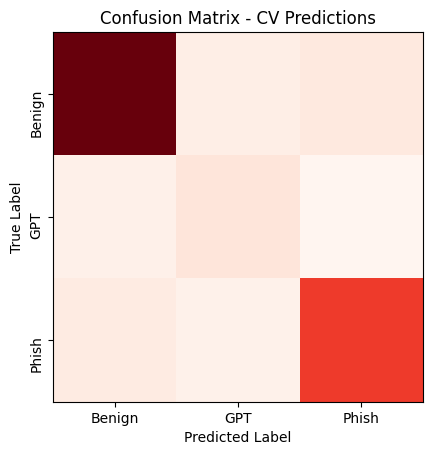

In [73]:
# ========================= Running Model =========================

model1 = RandomForestClassifier(n_estimators=50, random_state=20, max_depth=10, class_weight='balanced', min_samples_split=2).fit(X_train, y_train)
predictions = model1.predict(X_test)


kf = KFold(n_splits=5, shuffle=True, random_state=None)
cv_scores = cross_val_score(model1, X_train, y_train, cv=kf).mean()
cv_predict = cross_val_predict(model1, X_train, y_train, cv=kf)


# GScv = GridSearchCV(estimator=RandomForestClassifier(random_state=20, class_weight='balanced'),
#                     param_grid={
#                         'n_estimators': [10, 25, 50, 100, 200],
#                         'max_depth': [10, 20, 30, None],
#                         'min_samples_split': [2, 5, 10]
#                     },
#                     cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=20),
#                     n_jobs=-1,
#                     scoring='f1_weighted')

# GScv.fit(X_train, y_train)
# print(f'Best Hyper Parameters: {GScv.best_params_} and best score: {GScv.best_score_:.4f}')

print('Classification Report CV:')
print(f'{classification_report(y_train, cv_predict, target_names=target_names)}')
print(f"Average Cross-Validation Accuracy: {cv_scores.mean():.4f} with std: {cv_scores.std():.4f}")

from matplotlib import pyplot as plt

print("\nConfusion Matrix on CV Predictions:")
cm = confusion_matrix(y_train, cv_predict, labels=[0,1,2])
fig, ax = plt.subplots()
plt.title('Confusion Matrix - CV Predictions')
im = ax.imshow(cm, cmap='Reds')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
ax.set_xticks([0,1,2])
ax.set_yticks([0,1,2])
ax.set_xticklabels(['Benign', 'GPT', 'Phish'])
ax.set_yticklabels(['Benign', 'GPT', 'Phish'], rotation=90)

print("\n--- Test Set Performance ---")
print(f"Accuracy: {accuracy_score(y_test, predictions):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, predictions, target_names=target_names))
